# 😴 Sleep Stages Classification — EDA**SuperAI SS4 · Individual Hackathon 5** — rebuild 2026 · notebook นี้ทำ EDA อย่างเดียว (โค้ดจริงอยู่ใน `src/sleep_stage/`)คำถามที่ต้องตอบก่อนวางแผน1. 8 คอลัมน์นี้คือสัญญาณอะไร มาจากเครื่องอะไร และอัตราสุ่มจริงของแต่ละช่องเท่าไร2. label เป็นอะไรบ้าง สัดส่วนเท่าไร และ epoch หนึ่งยาวเท่าไร3. **test แต่ละไฟล์เรียงตามเวลาหรือไม่** — ถ้าใช่ เราต่อกลับเป็นคืนเดียวได้ และใช้ context ทั้งคืนได้4. คนละคนต่างกันแค่ไหน (ต้อง normalize ต่อคนหรือไม่) — test คือคนที่โมเดลไม่เคยเห็น5. feature ตัวไหนแยก W / N / R ได้จริง โดยเฉพาะ **R (REM)** ที่เป็นคลาสที่ยากที่สุด6. hypnogram มีโครงสร้างเวลาแบบไหน — พอจะใช้ HMM ช่วยได้ไหม

In [1]:
import sys, glob, os, re, warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import signal as sps
sys.path.insert(0, "../src")
from sleep_stage import CLASSES
from sleep_stage.config import load_config
from sleep_stage.data import read_train_night, read_test_night, train_dir, test_dir, subject_ids
from sleep_stage.features import COLUMNS, night_features
from sleep_stage.context import robust_z

cfg = load_config("../configs/default.yaml")
ASSETS = "../../../assets"
CACHE = cfg.resolve(cfg.data.cache_dir) / "v2"     # feature cache สร้างจาก `make cache`
ES = cfg.features.epoch_samples          # 1920 = 30 s @ 64 Hz
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25})
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
STAGE_NAME = {"W": "Wake", "N": "NREM", "R": "REM"}
COLOR = {"W": "#e4572e", "N": "#2e86ab", "R": "#7b2cbf"}

## 1. ไฟล์ · เครื่อง · อัตราสุ่มจริง`train/train/trainNNN.csv` = บันทึกทั้งคืนของคนหนึ่งคน (มีคอลัมน์ `Sleep_Stage`)`test/test_segment/testNNN/testNNN_00000.csv ...` = คืนเดียวกันแต่ **ถูกซอยเป็น epoch ละไฟล์** ไว้แล้ว (ไม่มี label)

In [2]:
tr_ids, te_ids = subject_ids(cfg)
print("train nights:", len(tr_ids), "| test nights:", len(te_ids))
print("test epochs per night:", {s: len(list((test_dir(cfg)/s).glob('*.csv'))) for s in te_ids})
raw, y = read_train_night(train_dir(cfg) / "train001.csv", ES)
print("\ntrain001:", raw.shape, "rows =", raw.shape[0] / ES, "epochs =", raw.shape[0] / 64 / 3600, "hours")
pd.DataFrame(raw[:5], columns=COLUMNS)

train nights: 83 | test nights: 10
test epochs per night: {'test001': 855, 'test002': 760, 'test003': 805, 'test004': 843, 'test005': 789, 'test006': 771, 'test007': 743, 'test008': 719, 'test009': 823, 'test010': 862}



train001: (1426560, 8) rows = 743.0 epochs = 6.191666666666666 hours


,BVP,ACC_X,ACC_Y,ACC_Z,TEMP,EDA,HR,IBI
0,25.610001,-22.0,-61.0,5.0,32.09,0.06532,72.849998,1.0625
1,23.450001,-22.0,-61.0,5.0,32.09,0.06532,72.849998,1.0625
2,21.990000,-22.0,-62.0,4.0,32.09,0.06532,72.849998,1.0625
3,21.139999,-22.0,-62.0,4.0,32.09,0.06532,72.849998,1.0625
4,20.520000,-19.0,-61.0,10.0,32.09,0.06532,72.849998,1.0625


8 คอลัมน์นี้ตรงกับสายรัดข้อมือ **Empatica E4** เป๊ะ ๆ (BVP = PPG ที่ข้อมือ, ACC 3 แกน, TEMP ผิวหนัง, EDA, HR และ IBI ที่เครื่องคำนวณให้)ชุดนี้คือ **DREAMT** (PhysioNet) — E4 + PSG ที่ sync กัน โฟลเดอร์ `data_64Hz` แล้วยุบ label เหลือ 3 คลาส> ⚠️ ไม่ใช่ EEG — วิธีคิดทั้งหมดจึงต้องเป็นแนว **cardio-respiratory + actigraphy** ไม่ใช่ spectral band ของสมอง

In [3]:
# อัตราสุ่มจริงของแต่ละคอลัมน์ อ่านจาก "ค่าเปลี่ยนทุกกี่ sample"
rows = []
for i, c in enumerate(COLUMNS):
    v = raw[:64 * 600, i]                      # 10 นาทีแรก
    gaps = np.diff(np.flatnonzero(np.diff(v) != 0))
    fastest = np.percentile(gaps, 10) if gaps.size > 5 else np.nan   # ช่วงที่สั้นที่สุด = คาบจริง
    rows.append(dict(column=c, changes_per_10min=int(gaps.size),
                     fastest_gap_samples=fastest, implied_hz=64.0 / fastest))
pd.DataFrame(rows).round(2)

,column,changes_per_10min,fastest_gap_samples,implied_hz
0,BVP,38380,1.0,64.00
1,ACC_X,9661,2.0,32.00
2,ACC_Y,5262,2.0,32.00
3,ACC_Z,8287,2.0,32.00
4,TEMP,328,64.0,1.00
5,EDA,1573,16.0,4.00
6,HR,588,64.0,1.00
7,IBI,7,49.6,1.29


ทุกคอลัมน์ถูก **upsample มาที่ 64 Hz แล้ว** โดยการซ้ำค่า (forward-fill) — ช่วงที่ค่าเปลี่ยนถี่ที่สุดบอกคาบจริง : BVP 64 Hz · ACC 32 Hz · EDA 4 Hz
ส่วน TEMP อ่านได้ 1 Hz เพราะค่าถูกปัดเป็น 0.01 °C จึงไม่เปลี่ยนทุก sample (ของจริง 4 Hz) และ HR เป็น 1 Hz จริง ๆส่วน **IBI เปลี่ยนค่านาน ๆ ครั้ง** เพราะ E4 รายงานเฉพาะ beat ที่มั่นใจ → จำนวนครั้งที่ IBI เปลี่ยนในหนึ่ง epoch จึงใช้เป็น *ตัวชี้คุณภาพสัญญาณ* ได้

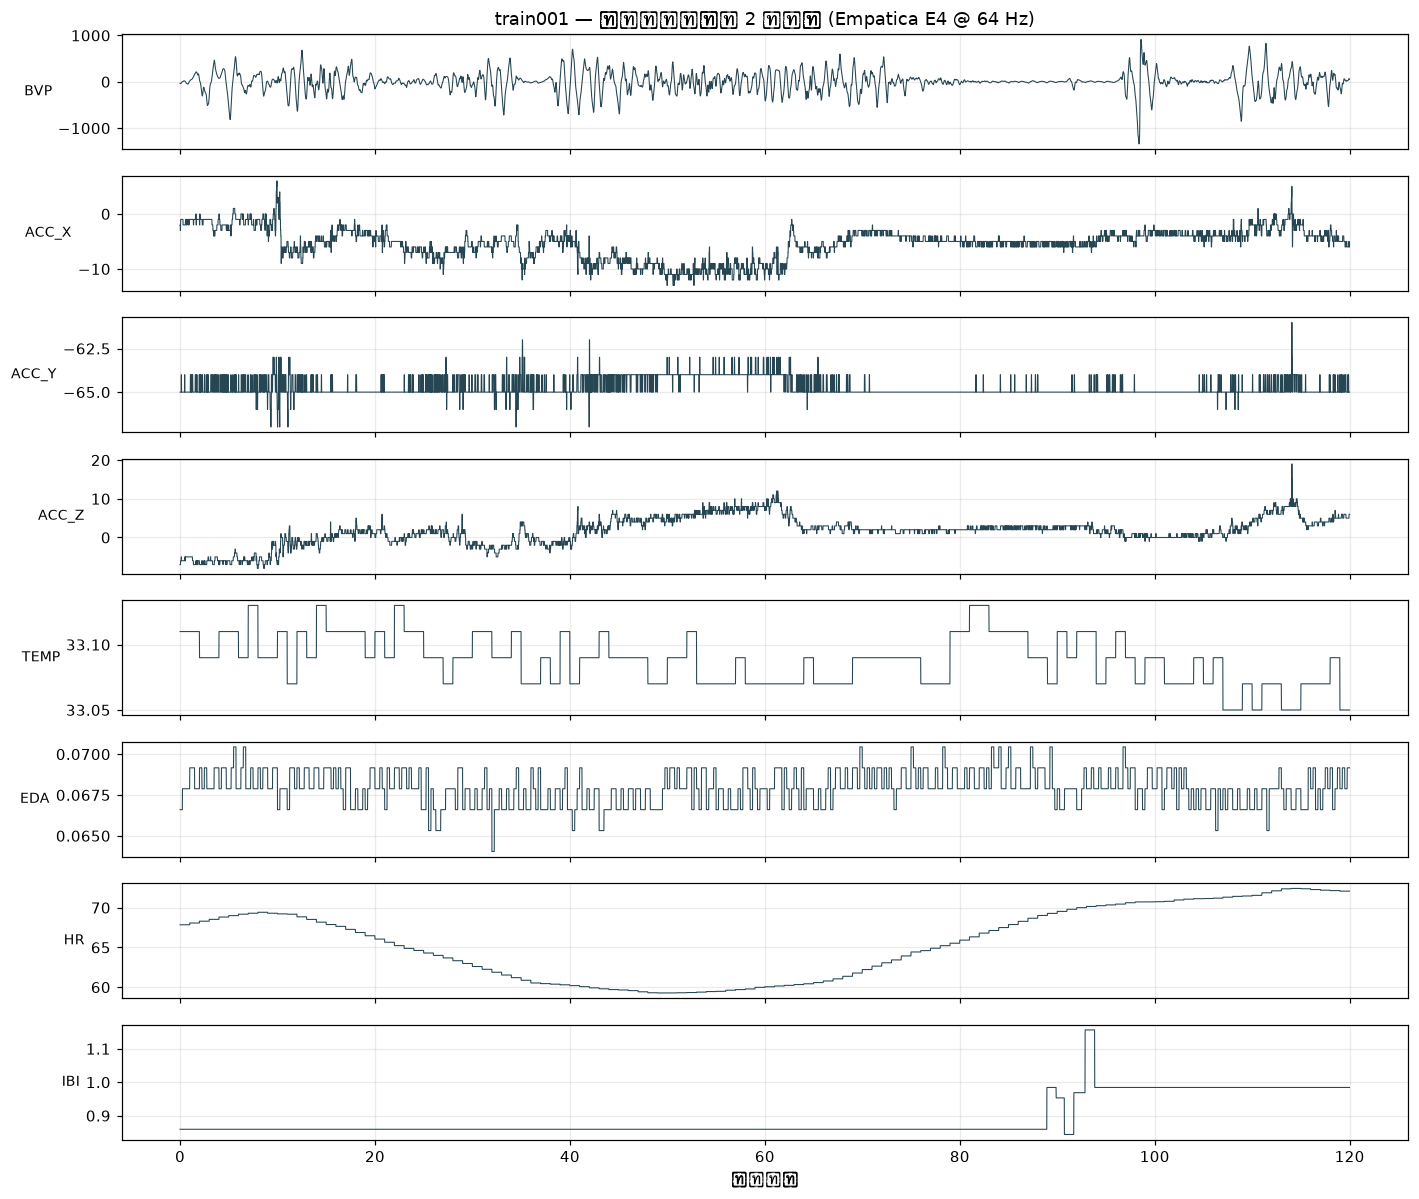

In [4]:
fig, axes = plt.subplots(8, 1, figsize=(13, 11), sharex=True)
seg = slice(64 * 1800, 64 * 1800 + 64 * 120)   # 2 นาที กลางคืน
t = np.arange(seg.stop - seg.start) / 64
for ax, (i, c) in zip(axes, enumerate(COLUMNS)):
    ax.plot(t, raw[seg, i], lw=.7, color="#264653")
    ax.set_ylabel(c, rotation=0, ha="right", va="center", fontsize=9)
axes[-1].set_xlabel("วินาที")
axes[0].set_title("train001 — สัญญาณดิบ 2 นาที (Empatica E4 @ 64 Hz)")
plt.tight_layout(); plt.savefig(f"{ASSETS}/sleep_signals_2min.png", bbox_inches="tight"); plt.show()

## 2. Label: 3 คลาส และ hypnogram

In [5]:
counts, lengths = [], {}
for s in tr_ids:
    d = np.load(CACHE / f"{s}.npz")
    lengths[s] = len(d["y"]); counts.append(np.bincount(d["y"], minlength=3))
counts = np.array(counts)
share = pd.DataFrame(counts, columns=CLASSES, index=list(lengths)).assign(epochs=list(lengths.values()))
print("รวมทุกคืน:", dict(zip(CLASSES, counts.sum(0))), "= สัดส่วน", np.round(counts.sum(0) / counts.sum(), 3))
print("ความยาวคืน (epoch): min %d  median %d  max %d" % (min(lengths.values()), int(np.median(list(lengths.values()))), max(lengths.values())))
share.head()

รวมทุกคืน: {'N': np.int64(43607), 'R': np.int64(7135), 'W': np.int64(15865)} = สัดส่วน [0.655 0.107 0.238]
ความยาวคืน (epoch): min 711  median 807  max 955


,N,R,W,epochs
train001,398,80,265,743
train002,596,119,114,829
train003,588,0,248,836
train004,524,116,93,733
train005,591,0,252,843


**N ≈ 64 % · W ≈ 27 % · R ≈ 9 %** — R เป็นคลาสหายาก และ metric ของ competition คือ **macro F1** ซึ่งให้น้ำหนัก R เท่ากับ Nเดาคลาสเดียวทั้งหมดได้ macro-F1 ≈ 0.26 เท่านั้น (ตรงกับคะแนน submission เดิมที่ทำนาย N อย่างเดียว)

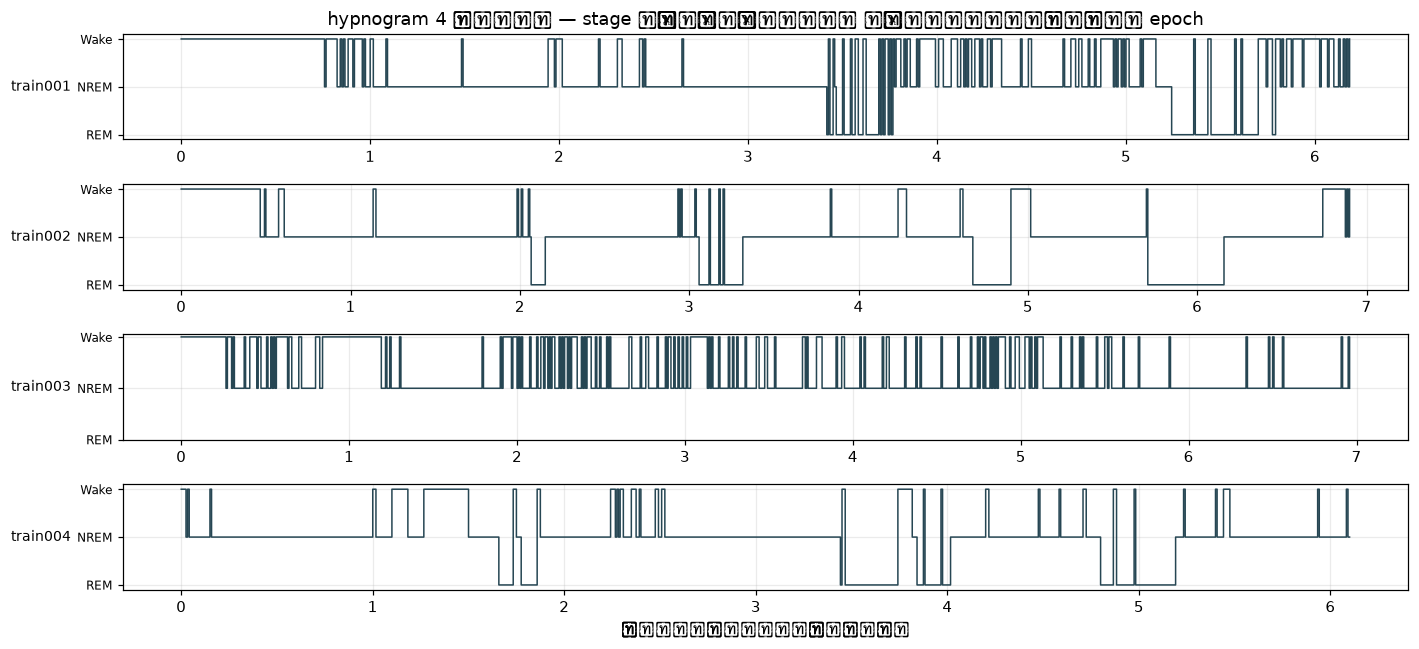

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(13, 6), sharex=False)
for ax, s in zip(axes, tr_ids[:4]):
    d = np.load(CACHE / f"{s}.npz")
    yy = d["y"]
    ax.step(np.arange(len(yy)) * 0.5 / 60, [ {0:1, 1:0, 2:2}[v] for v in yy ], where="post", lw=1, color="#264653")
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["REM", "NREM", "Wake"], fontsize=8)
    ax.set_ylabel(s, rotation=0, ha="right", va="center", fontsize=9)
axes[-1].set_xlabel("ชั่วโมงนับจากเริ่มบันทึก")
axes[0].set_title("hypnogram 4 คืนแรก — stage อยู่เป็นช่วงยาว ไม่กระโดดสลับทีละ epoch")
plt.tight_layout(); plt.savefig(f"{ASSETS}/sleep_hypnograms.png", bbox_inches="tight"); plt.show()

## 3. ✅ ข้อค้นพบสำคัญที่สุด — test เรียงตามเวลาและต่อกันสนิทถ้าไฟล์ `testNNN_00000 … 00854` เรียงตามเวลาจริง เราจะ **ต่อกลับเป็นคืนเดียว** แล้วใช้โมเดลที่มอง context ทั้งคืนได้วิธีพิสูจน์: TEMP / EDA / HR เป็นสัญญาณที่เปลี่ยนช้ามาก ถ้าเรียงถูก ค่าสุดท้ายของไฟล์ที่ *i* ต้องต่อกับค่าแรกของไฟล์ *i+1* ได้แนบสนิท

In [7]:
files = sorted((test_dir(cfg) / "test001").glob("*.csv"), key=lambda p: int(p.stem.split("_")[1]))[:120]
segs = [pd.read_csv(f, encoding="utf-8-sig")[COLUMNS].to_numpy(np.float32) for f in files]
rows = []
rng = np.random.default_rng(0)
for name, i in [("TEMP", 4), ("EDA", 5), ("HR", 6)]:
    last = np.array([s[-1, i] for s in segs[:-1]]); first = np.array([s[0, i] for s in segs[1:]])
    rows.append(dict(signal=name, gap_adjacent=np.median(np.abs(last - first)),
                     gap_shuffled=np.median(np.abs(last - rng.permutation(first)))))
print(pd.DataFrame(rows).round(4).to_string(index=False))

signal  gap_adjacent  gap_shuffled
  TEMP        0.0100        0.2700
   EDA        0.0013        0.0218
    HR        0.0300        1.3300


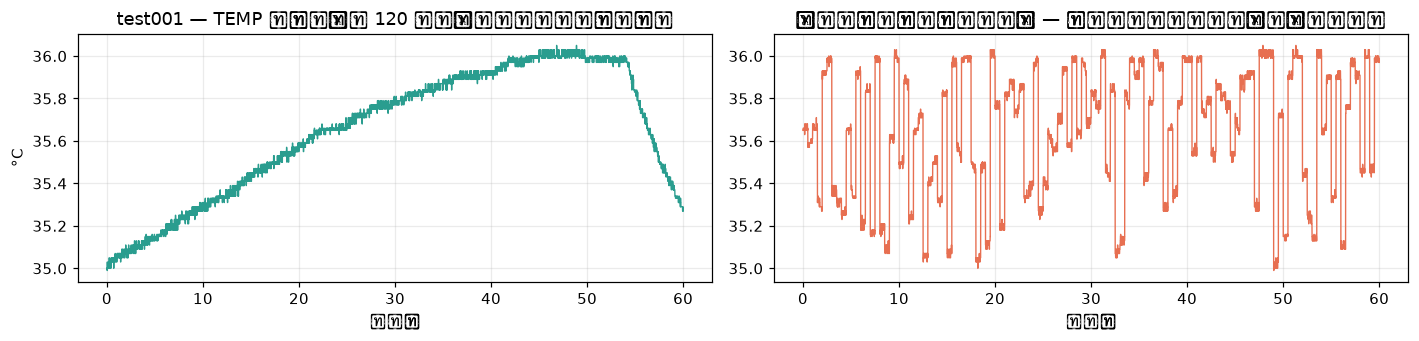

In [8]:
temp = np.concatenate([s[:, 4] for s in segs])
fig, ax = plt.subplots(1, 2, figsize=(13, 3.2))
ax[0].plot(np.arange(len(temp)) / 64 / 60, temp, lw=.9, color="#2a9d8f")
ax[0].set_title("test001 — TEMP หลังต่อ 120 ไฟล์ตามเลขลำดับ"); ax[0].set_xlabel("นาที"); ax[0].set_ylabel("°C")
order = rng.permutation(len(segs))
ax[1].plot(np.arange(len(temp)) / 64 / 60, np.concatenate([segs[i][:, 4] for i in order]), lw=.9, color="#e76f51")
ax[1].set_title("ถ้าสลับลำดับไฟล์ — สัญญาณขาดเป็นฟันปลา"); ax[1].set_xlabel("นาที")
plt.tight_layout(); plt.savefig(f"{ASSETS}/sleep_test_contiguous.png", bbox_inches="tight"); plt.show()

ต่อกันสนิททุกช่อง (ต่างกันแค่ระดับความละเอียดของ sensor) ส่วนแบบสุ่มลำดับต่างกันเป็นสิบเท่า→ **test เรียงตามเวลา** เราจึงทำ sequence model ทั้งคืน + Viterbi ได้ ซึ่งเป็นสิ่งที่รอบเดิม (มองทีละ epoch แยกกัน) ทิ้งไปทั้งหมด

## 4. คนละคนต่างกันแค่ไหน — ทำไมต้อง normalize ต่อคนtest คือคน 10 คนที่โมเดลไม่เคยเห็น ถ้า feature ยังผูกกับ "ระดับ" ของแต่ละคน (HR พัก, อุณหภูมิผิว) โมเดลจะย้ายข้ามคนไม่ได้

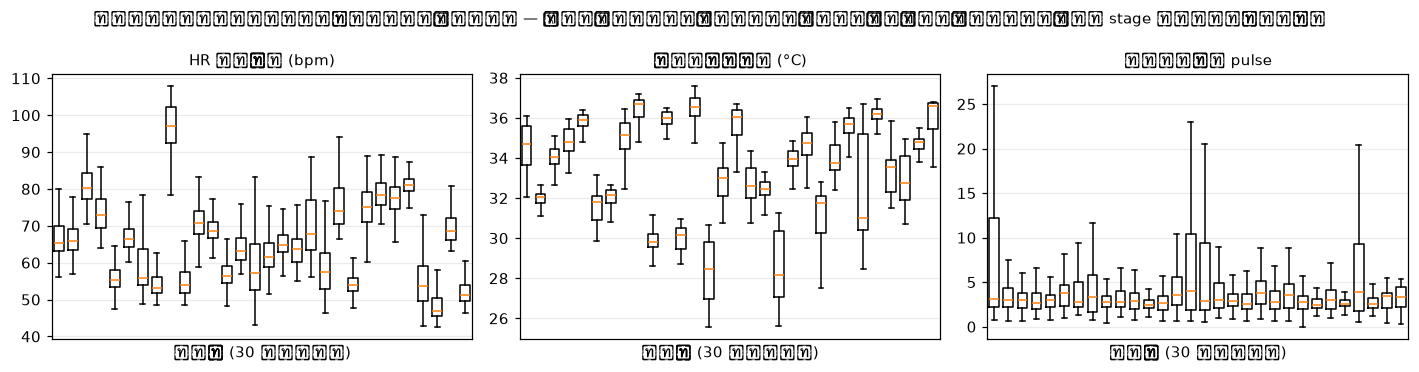

In [9]:
feat = {s: np.load(CACHE / f"{s}.npz") for s in tr_ids}
names = [str(n) for n in feat[tr_ids[0]]["names"]]
def col(s, n): return feat[s]["X"][:, names.index(n)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, n, lab in zip(axes, ["e4_hr_mean", "tmp_mean", "ppg_amp"], ["HR เฉลี่ย (bpm)", "อุณหภูมิผิว (°C)", "ความสูง pulse"]):
    data = [col(s, n) for s in tr_ids[:30]]
    ax.boxplot(data, showfliers=False, widths=.7)
    ax.set_title(lab, fontsize=10); ax.set_xlabel("คนที่ (30 คนแรก)"); ax.set_xticks([])
plt.suptitle("การกระจายภายในคืนของแต่ละคน — ช่องว่างระหว่างคนกว้างกว่าช่องว่างระหว่าง stage ในคนเดียวกัน", fontsize=10)
plt.tight_layout(); plt.savefig(f"{ASSETS}/sleep_subject_variability.png", bbox_inches="tight"); plt.show()

ค่ากลางของ HR ต่างกันได้ 45–90 bpm ระหว่างคน ขณะที่ความต่างระหว่าง NREM กับ REM ในคนเดียวกันอยู่ระดับไม่กี่ bpm→ ทุก feature ถูก **robust z-score ด้วย median/IQR ของคืนตัวเอง** ใน `context.py` ก่อนเข้าโมเดลเสมอ

## 5. feature ไหนแยก stage ได้จริง (โดยเฉพาะ REM)ฟิสิโอโลยีที่ใช้ได้จากข้อมือ: REM = ระบบประสาทซิมพาเทติกเด่น **หายใจไม่สม่ำเสมอ** กล้ามเนื้อ atonia (ไม่ขยับ)NREM = หายใจเป็นจังหวะสม่ำเสมอ HRV ด้าน HF สูง · Wake = ขยับ + HR สูง + EDA แกว่ง

In [10]:
show = ["e4_hr_mean", "e4_hr_sdsd", "hrv_rmssd", "frq_lf_hf", "riiv_conc", "riiv_entropy",
        "rsa_entropy", "ppg_amp", "acc_count", "acc_still_frac", "tmp_slope", "eda_scr_n"]
idx = [names.index(n) for n in show]
rows = []
for s_ in tr_ids:
    Z, yy = robust_z(feat[s_]["X"])[:, idx], feat[s_]["y"]
    for k, c in enumerate(CLASSES):
        if (yy == k).sum() < 20: continue
        rows.append(dict(stage=c, **dict(zip(show, np.median(Z[yy == k], axis=0)))))
prof = pd.DataFrame(rows).groupby("stage")[show].mean().reindex(["W", "N", "R"])
prof.round(2)

,e4_hr_mean,e4_hr_sdsd,hrv_rmssd,frq_lf_hf,riiv_conc,riiv_entropy,rsa_entropy,ppg_amp,acc_count,acc_still_frac,tmp_slope,eda_scr_n
stage,,,,,,,,,,,,
W,0.52,0.70,0.32,0.33,-0.23,0.19,0.01,0.44,0.52,-0.13,0.00,0.21
N,-0.12,-0.13,-0.07,-0.09,0.10,-0.09,-0.02,-0.04,-0.13,0.01,0.02,0.03
R,0.13,0.16,-0.04,0.07,-0.01,0.00,0.06,0.08,-0.11,-0.02,-0.22,0.07


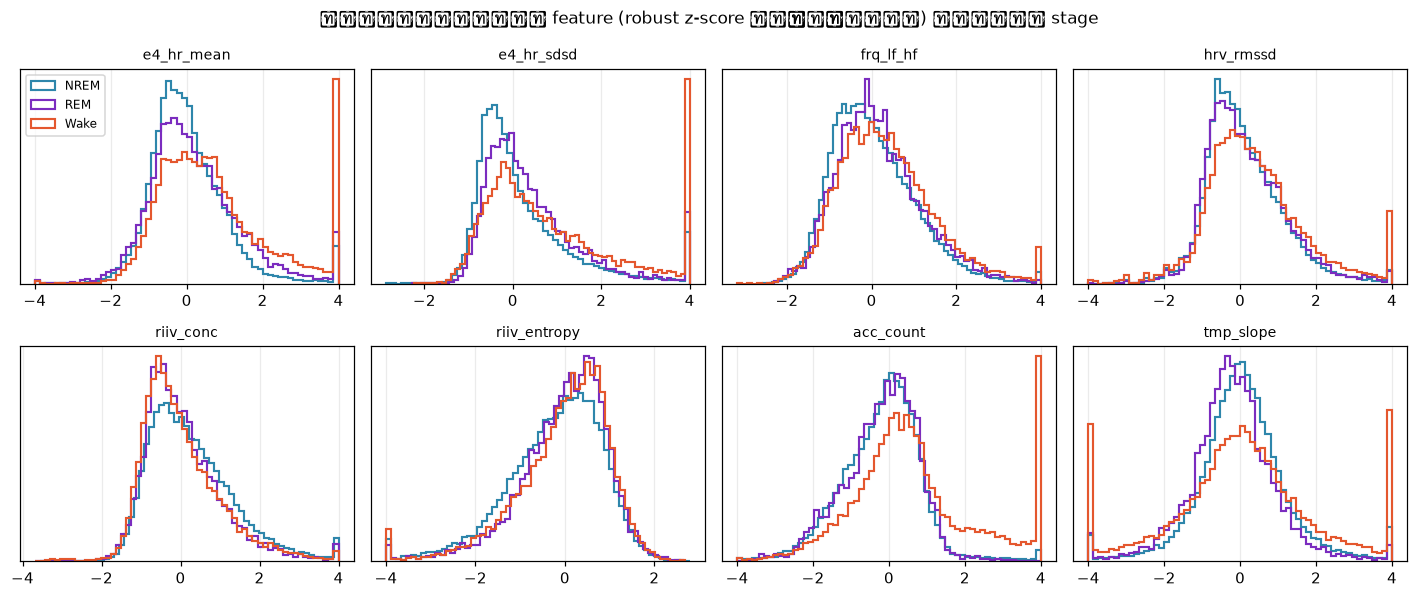

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
Zs = {s_: robust_z(feat[s_]["X"]) for s_ in tr_ids}
for ax, n in zip(axes.ravel(), ["e4_hr_mean", "e4_hr_sdsd", "frq_lf_hf", "hrv_rmssd",
                                "riiv_conc", "riiv_entropy", "acc_count", "tmp_slope"]):
    j = names.index(n)
    for k, c in enumerate(CLASSES):
        v = np.concatenate([Zs[s_][feat[s_]["y"] == k, j] for s_ in tr_ids])
        ax.hist(np.clip(v, -4, 4), bins=60, histtype="step", density=True, lw=1.4,
                color=COLOR[c], label=STAGE_NAME[c])
    ax.set_title(n, fontsize=9); ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.suptitle("การกระจายของ feature (robust z-score ในคืนตัวเอง) แยกตาม stage", fontsize=11)
plt.tight_layout(); plt.savefig(f"{ASSETS}/sleep_stage_features.png", bbox_inches="tight"); plt.show()

อ่านจากตาราง/รูป- `riiv_conc` (ความคมของยอดสเปกตรัมการหายใจ) **N สูงกว่า R** และ `riiv_entropy` / `rsa_entropy` **R สูงกว่า N** — ตรงกับตำราว่า REM หายใจไม่สม่ำเสมอ นี่คือสัญญาณ REM ที่แรงที่สุดที่อ่านได้จากข้อมือ- `frq_lf_hf` R > N — ซิมพาเทติกเด่นใน REM- `acc_count` / `acc_still_frac` แยก **W** ออกจากที่เหลือได้ดี แต่แยก N กับ R แทบไม่ได้เลย (ทั้งคู่นิ่ง)- `e4_hr_sdsd` (HR แกว่งใน 30 วินาที) W สูงสุด→ ไม่มี feature เดี่ยว ๆ ที่แยก R ได้ ต้องอาศัยหลายตัวรวมกัน **บวกกับ context เวลา**

## 6. โครงสร้างเวลาของ hypnogram → ทำไม Viterbi ถึงช่วย

In [12]:
A = np.ones((3, 3))
bouts = {c: [] for c in CLASSES}
for s in tr_ids:
    yy = feat[s]["y"].astype(int)
    np.add.at(A, (yy[:-1], yy[1:]), 1.0)
    cuts = np.flatnonzero(np.diff(yy)) + 1
    for seg in np.split(yy, cuts):
        bouts[CLASSES[seg[0]]].append(len(seg) * 0.5)
A = A / A.sum(1, keepdims=True)
print("transition matrix (แถว = stage ปัจจุบัน, หลัก = stage ถัดไป)")
print(pd.DataFrame(A, index=CLASSES, columns=CLASSES).round(3))
print("\nความยาว bout (นาที) median:", {c: float(np.median(v)) for c, v in bouts.items()})
print("สัดส่วน epoch ที่ stage เปลี่ยน: %.3f" % (1 - np.trace(A * np.bincount(np.concatenate([feat[s]['y'] for s in tr_ids]).astype(int)).reshape(-1,1) / len(np.concatenate([feat[s]['y'] for s in tr_ids]))).sum()))

transition matrix (แถว = stage ปัจจุบัน, หลัก = stage ถัดไป)
       N      R      W
N  0.938  0.009  0.053
R  0.029  0.929  0.043
W  0.159  0.008  0.833

ความยาว bout (นาที) median: {'N': 2.0, 'R': 4.5, 'W': 0.5}
สัดส่วน epoch ที่ stage เปลี่ยน: 0.088


ความน่าจะเป็นที่จะ **อยู่ stage เดิม** ต่ออีก 30 วินาทีสูงกว่า 0.9 ทุกคลาส — hypnogram จริงไม่กระพริบทีละ epochแต่ classifier ที่ตัดสินทีละ epoch จะกระพริบ เพราะไม่มีอะไรห้าม → เอา transition matrix นี้ไปถอดรหัสทั้งคืนด้วย **Viterbi**ช่วย macro-F1 ได้จริง (+0.04 ในรุ่น LightGBM) และช่วย R มากที่สุด เพราะ R เป็นคลาสที่โดน "กระพริบ" ทำลายง่ายที่สุด

## สรุปแผน| ข้อค้นพบ | สิ่งที่ทำใน `src/sleep_stage/` ||---|---|| E4 ที่ข้อมือ ไม่ใช่ EEG | feature เป็น HRV · การหายใจ · actigraphy · EDA · อุณหภูมิ (`features.py`) || ทุกช่อง upsample มาที่ 64 Hz | อ่านอัตราจริงคืน แล้วคำนวณบนช่วงเวลาที่ถูกต้อง || BVP ที่ข้อมือ noise สูง | ใช้สเปกตรัม 30 วินาทีกำกับการหา beat + เก็บ `ppg_card_conc` เป็นตัวบอกคุณภาพ || **test เรียงตามเวลา** | ต่อกลับเป็นคืนเดียว → BiLSTM/TCN ทั้งคืน + Viterbi (`models.py`, `smooth.py`) || คนต่างกันมาก | robust z-score ต่อคืน (`context.py`) || R หายาก + metric = macro F1 | class weight + feature การหายใจ + Viterbi || stage อยู่เป็นช่วงยาว | HMM transition matrix จาก train (`smooth.py`) || test = คนใหม่ | CV แบ่ง fold ทั้งคืน ไม่เคยแยกคนเดียวกันข้าม fold (`train.py`) |